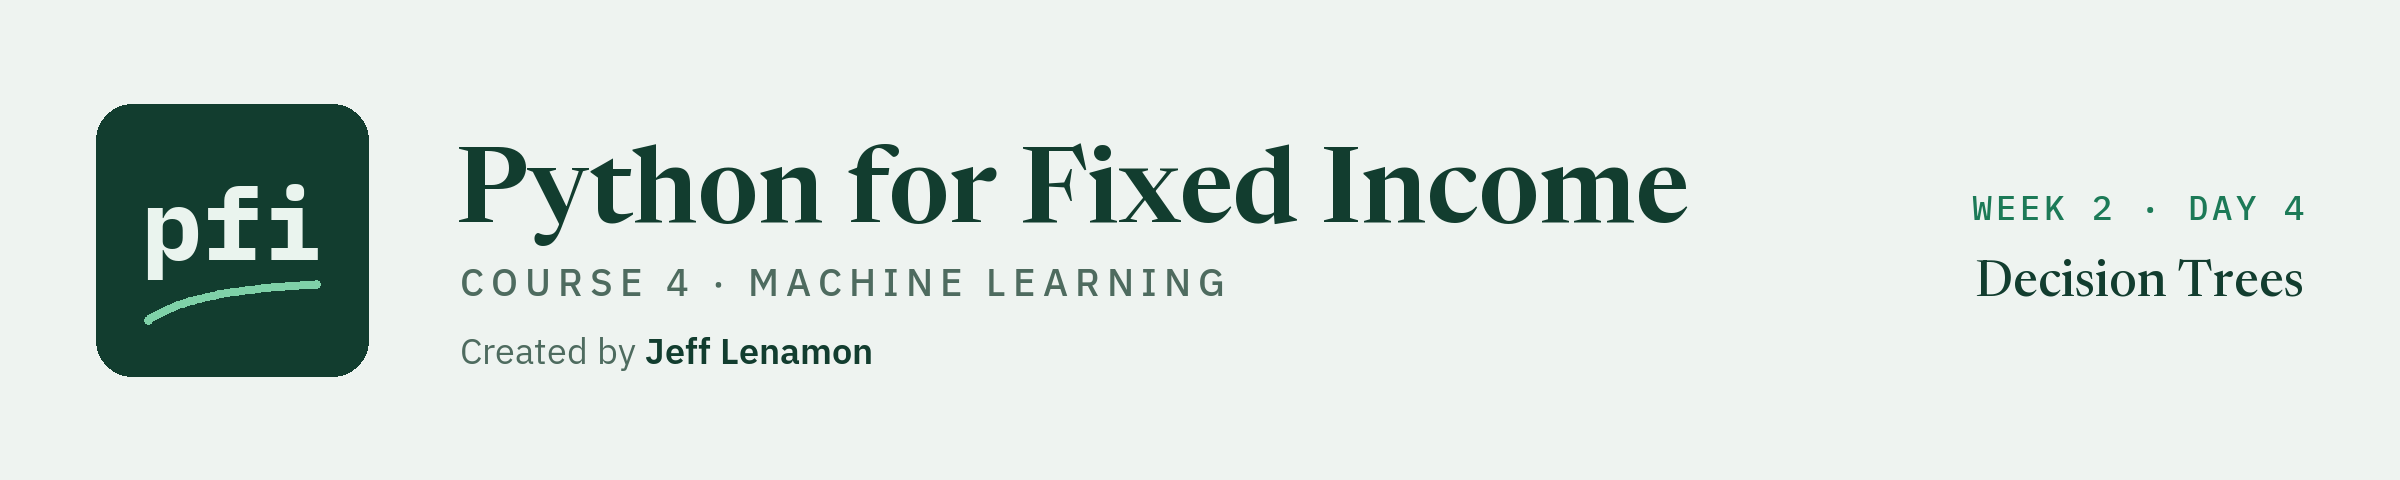

# Decision Trees

Week 2, Day 4. A decision tree is a set of yes or no questions fitted to rows. Today: how a tree picks a question, why a tree left to grow learns its training rows by heart, how class weights and pruning rein it in, how to read one, and what feature importance does and does not say.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day4/09_decision_trees.ipynb)

Days 6 to 8 fitted a logistic regression to the card file: one equation, a weight per column, and a probability for every account. Today's model works another way. A **decision tree** asks a question of one column, splits the accounts in two, and asks another question on each side, until it stops. Its output for an account is the share of defaults among the training accounts that ended in the same place.

Trees are easy to read and easy to overfit. Most of today is about the second fact: a tree grown with scikit-learn's default settings fits its training rows almost perfectly and does much worse on rows it never saw, and the rest of the day is the three ways to stop that: class weights, pre-pruning, and post-pruning.

**The week 2 rules, as on every day this week.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16: 30,000 credit card accounts, with payment records from April to September 2005 and an outcome for the following month. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** The file has four columns that describe people: `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE`. No model in this course uses them. The course describes a file and builds no lending rule; a model that used these columns would sort people by them; and leaving them out does not make a model neutral, because other columns can carry the same information. Every tree today uses the other 19 columns.
* **Undocumented codes are kept**, as in notebook 16. The documentation defines the repayment status codes -1 ("pay duly") and 1 to 9 (a delay of that many months), not -2 or 0, which the file holds on most accounts. The `PAY_` columns go into the model as the numbers they are; treating the codes as an ordered number is a modelling choice, and a tree's thresholds on them must be read with that in mind.
* **The 60/20/20 split.** 18,000 training rows fit, 6,000 validation rows choose and report, and 6,000 test rows stay closed until day 10, where they are opened once. Every number today is on training or validation rows. Settings are chosen by cross-validation inside the training rows, never on the test rows.
* **A model's output is described, never acted on.** A tree's output is the model probability of default in this file, or a flag at a threshold. It is not a credit decision for any person, and a tree's rules describe how this dataset splits; they are never a rule for lending.

Today you will:

1. Fit a tree with one question and read it.
2. Work that question's Gini impurity by hand from counts, and match the tree.
3. Grow a tree with the default settings and measure how badly it overfits.
4. Read a tree as a picture (depth 2) and as text rules (depth 3).
5. Weight the rare class with `class_weight="balanced"`.
6. Pre-prune with `max_depth` and `min_samples_leaf`, chosen by `GridSearchCV` with the new `mlkit.cv_folds()`.
7. Post-prune with the cost-complexity path, `ccp_alpha` chosen by cross-validation.
8. Read impurity importance and permutation importance, and say what neither means.
9. Show that scaling does not change a tree.

Q. Set up today's work folder: the thread settings, the seed, the data files, and `mlkit.py` as it stood at the end of day 8.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_09_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_09_sazjyutx, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall']


* The module holds the functions of days 1 to 8, among them `assert_disjoint`, `confusion_counts`, `classification_metrics`, and `threshold_for_recall`. Today adds `cv_folds`.

## 9.1 A Tree as Questions

A tree is a flowchart fitted to data. The words:

| Word | Meaning |
| --- | --- |
| Node | A group of training accounts |
| Root | The first node: every training account |
| Split | A question on one column, "is this value at most t?", that sends each account left (yes) or right (no) |
| Leaf | A node with no question: where an account ends |
| Depth | The number of questions from the root to the deepest leaf |
| The tree's output | The share of defaults among the training accounts in the account's leaf |

Q. Load the card accounts and keep the 19 columns the course uses as features.

In [5]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"

# the 19 feature columns: the credit limit, six repayment statuses, six bills, six payments (NT dollars)
FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
# the four columns that describe people are never features: stop if one slips in
assert not set(FEATURES) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

X, y = card[FEATURES], card[TARGET]
print(f"{len(card):,} accounts, {len(FEATURES)} features; {y.sum():,} defaults, {y.mean():.2%} of accounts")

30,000 accounts, 19 features; 6,636 defaults, 22.12% of accounts


Q. Split the accounts 60/20/20, stratified, with the course's seed, and prove no account is in two parts.

In [6]:
from sklearn.model_selection import train_test_split

# first the 20 percent test rows, put away until day 10; then a quarter of the rest as validation rows
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# no account in two parts
mlkit.assert_disjoint(X_train.index, X_valid.index)
mlkit.assert_disjoint(X_train.index, X_test.index)
mlkit.assert_disjoint(X_valid.index, X_test.index)
for name, part in [("training", y_train), ("validation", y_valid), ("test", y_test)]:
    print(f"{name:10} rows: {len(part):6,}; default rate {part.mean():.2%}")

training   rows: 18,000; default rate 22.12%
validation rows:  6,000; default rate 22.12%
test       rows:  6,000; default rate 22.12%


* 18,000, 6,000, and 6,000 rows with the same default rate in each, as stratifying promises. The test rows are not touched again today.

Q. Fit a tree that may ask one question, and print it.

In [7]:
from sklearn.tree import DecisionTreeClassifier, export_text

# max_depth=1: one question. random_state=SEED settles ties between equally good questions the same way every run
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED)
stump.fit(X_train, y_train)

# the tree as text; show_weights prints the training accounts in each leaf as [no default, default]
print(export_text(stump, feature_names=FEATURES, show_weights=True))

|--- PAY_0 <= 1.50
|   |--- weights: [13455.00, 2660.00] class: 0
|--- PAY_0 >  1.50
|   |--- weights: [563.00, 1322.00] class: 1



* Of the 19 columns and every threshold in each, the tree chose **`PAY_0 <= 1.5`**: the repayment status in September 2005. Left are the 16,115 accounts with codes -2, -1, 0, or 1 (2,660 defaults, 16.5 percent); right the 1,885 accounts with a delay of two months or more (1,322 defaults, 70.1 percent).
* The threshold 1.5 sits halfway between the codes 1 and 2: a tree puts its thresholds between values it saw. Two of the four codes on the left, -2 and 0, are the ones the documentation does not define.
* This is how this file splits, in its training rows. It is not a rule for lending.

## 9.2 Gini Impurity, and a Split by Hand

A tree chooses the question that leaves its two groups as **pure** as possible: each as close as it can be to all defaults or no defaults. scikit-learn's default measure is **Gini impurity**. For a group with a share p of defaults:

Gini = 1 - p^2 - (1 - p)^2

It is 0 for a pure group (p = 0 or 1) and at most 0.5, for a group split half and half. A split is scored by the **weighted Gini** of its two sides, each weighted by its share of the accounts, and the tree keeps the question with the largest **decrease** from the parent's Gini.

Q. Work the root split `PAY_0 <= 1.5` by hand, from counts.

In [8]:
def gini(defaults, accounts):
    """Gini impurity of a group from its count of defaults and of accounts: 1 - p^2 - (1 - p)^2."""
    share = defaults / accounts
    return 1 - share ** 2 - (1 - share) ** 2

# the two sides of the question, on the training rows
goes_left = X_train["PAY_0"] <= 1.5
counts = pd.DataFrame({
    "accounts": [len(y_train), goes_left.sum(), (~goes_left).sum()],
    "defaults": [y_train.sum(), y_train[goes_left].sum(), y_train[~goes_left].sum()],
}, index=["all training rows", "left: PAY_0 <= 1.5", "right: PAY_0 > 1.5"])
counts["share of defaults"] = counts["defaults"] / counts["accounts"]
counts["gini"] = gini(counts["defaults"], counts["accounts"])

# the weighted Gini of the two sides, and the decrease from the parent
weights = counts["accounts"].iloc[1:] / counts["accounts"].iloc[0]
weighted_gini = (weights * counts["gini"].iloc[1:]).sum()
decrease = counts["gini"].iloc[0] - weighted_gini
print(f"weighted Gini of the two sides {weighted_gini:.4f}; decrease from the parent {decrease:.4f}")
counts.round(4)

weighted Gini of the two sides 0.2906; decrease from the parent 0.0539


,accounts,defaults,share of defaults,gini
all training rows,18000,3982,0.2212,0.3446
left: PAY_0 <= 1.5,16115,2660,0.1651,0.2756
right: PAY_0 > 1.5,1885,1322,0.7013,0.4189


* The parent's Gini is 0.3446: with 22.1 percent defaults, p^2 + (1 - p)^2 is 0.6554. The left side is purer (0.2756), the right side less pure (0.4189) because it is closer to half and half, and the weighted Gini is 0.2906: a decrease of 0.0539.

Q. Does the tree hold the same numbers?

In [9]:
# tree_.impurity holds each node's Gini: node 0 is the root, nodes 1 and 2 its left and right children
tree_gini = stump.tree_.impurity
for node, name in enumerate(counts.index):
    print(f"{name:20} by hand {counts['gini'].iloc[node]:.4f}   tree {tree_gini[node]:.4f}   within 1e-12: {abs(counts['gini'].iloc[node] - tree_gini[node]) < 1e-12}")

all training rows    by hand 0.3446   tree 0.3446   within 1e-12: True
left: PAY_0 <= 1.5   by hand 0.2756   tree 0.2756   within 1e-12: True
right: PAY_0 > 1.5   by hand 0.4189   tree 0.4189   within 1e-12: True


Q. Why 1.5 and not another threshold on `PAY_0`? Score every threshold between the codes the file holds near the middle.

In [10]:
# the decrease in Gini for each threshold halfway between two neighbouring codes
rows = []
for threshold in [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5]:
    side = X_train["PAY_0"] <= threshold
    left_gini, right_gini = gini(y_train[side].sum(), side.sum()), gini(y_train[~side].sum(), (~side).sum())
    weighted = (side.mean() * left_gini) + ((~side).mean() * right_gini)
    rows.append({"threshold": threshold, "accounts left": side.sum(), "decrease": counts["gini"].iloc[0] - weighted})
pd.DataFrame(rows).set_index("threshold").round(4)

,accounts left,decrease
threshold,,
-1.5,1620,0.0018
-0.5,5039,0.0037
0.5,13846,0.0487
1.5,16115,0.0539
2.5,17733,0.0080
3.5,17921,0.0014


* 1.5 gives the largest decrease (0.0539); the next best, 0.5, gives 0.0487. The tree does this for every one of the 19 columns at every threshold, keeps the best, then repeats it inside each side. That search is all a tree's fitting is.

## 9.3 The Default Tree, and Why It Overfits

With scikit-learn's default settings a tree keeps splitting until every leaf is pure or cannot be split again. Nothing stops it.

Q. Write one small function that reports a fitted model's ROC AUC, and its recall and precision when accounts are flagged at a probability of at least 0.5, on the rows given.

In [11]:
from sklearn.metrics import roc_auc_score

def tree_report(model, X_rows, y_rows):
    """ROC AUC of the model's probabilities, and recall and precision of the flags at proba >= 0.5, on the rows given."""
    proba = model.predict_proba(X_rows)[:, 1]
    flags = (proba >= 0.5).astype(int)
    metrics = mlkit.classification_metrics(y_rows, flags)
    return {"roc_auc": roc_auc_score(y_rows, proba), "recall": metrics["recall"], "precision": metrics["precision"]}

* ROC AUC (day 8) ranks the accounts by probability and needs no threshold, so it is the course's number for comparing models on the card file. Recall and precision at 0.5 show what the flags catch. The flag rule is the course's: a probability **at least** the threshold.

Q. Grow the default tree and compare its training and validation numbers.

In [12]:
# every setting at its default: the tree splits until its leaves are pure
default_tree = DecisionTreeClassifier(random_state=SEED)
default_tree.fit(X_train, y_train)
print(f"depth {default_tree.get_depth()}, leaves {default_tree.get_n_leaves():,}, "
      f"{len(X_train) / default_tree.get_n_leaves():.1f} training accounts per leaf on average")

pd.DataFrame({"training rows": tree_report(default_tree, X_train, y_train),
              "validation rows": tree_report(default_tree, X_valid, y_valid)}).T.round(4)

depth 38, leaves 2,750, 6.5 training accounts per leaf on average


,roc_auc,recall,precision
training rows,0.9997,0.9709,0.9895
validation rows,0.6161,0.4032,0.3888


* Depth 38 and 2,750 leaves for 18,000 accounts. On its training rows the tree's ROC AUC is 0.9997: it has nearly memorised them. On validation rows it is 0.6161, and recall at 0.5 falls from 0.9709 to 0.4032. That gap is **overfitting**: a model that learned the training rows' noise as if it were pattern.
* The numbers are the model probability of default in this file and the flags at threshold 0.5. In a pure leaf the probability is 0 or 1, so the default tree's probabilities are almost all 0 or 1: it is certain about every account and wrong about many.

Q. Why is training recall not exactly 1, if the tree splits until its leaves are pure?

In [13]:
# accounts identical in all 19 feature columns, grouped, with the number of different outcomes in each group
same_features = X_train.assign(outcome=y_train.to_numpy()).groupby(FEATURES)["outcome"].agg(["size", "nunique"])
mixed = same_features[same_features["nunique"] > 1]
print(f"{len(mixed)} groups of identical accounts hold both outcomes: {mixed['size'].sum()} training accounts")

48 groups of identical accounts hold both outcomes: 413 training accounts


* No question can separate two accounts with the same values, so 48 leaves stay mixed. A leaf of one default and one non-default gives 0.5, which the course's rule flags. These are different accounts with the same numbers, kept as Course 1 kept the file's repeated rows.

## 9.4 Reading a Tree: a Picture and Rules

A tree of depth 38 cannot be read. A tree limited to two or three questions can, which is how the course draws one. `plot_tree` draws it; `export_text` prints it as rules.

Q. Draw a tree of depth 2.

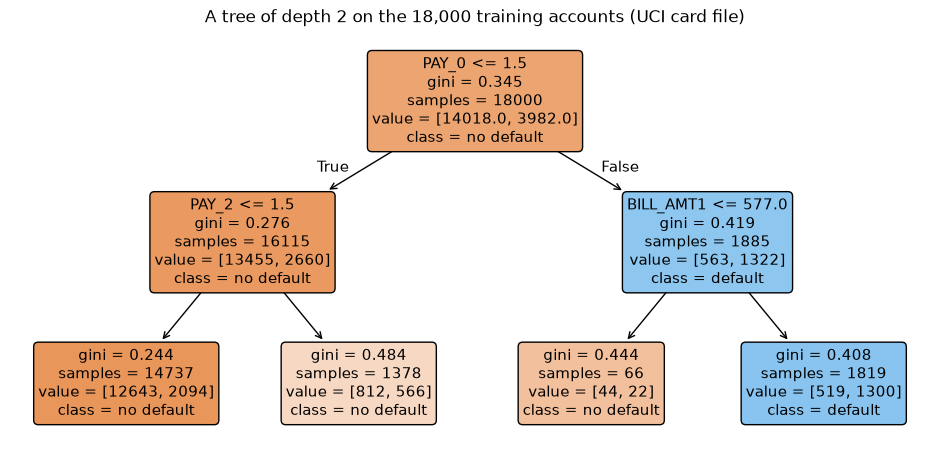

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree2 = DecisionTreeClassifier(max_depth=2, random_state=SEED)
tree2.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(12, 5.5))
# each box: the question, its Gini, the training accounts, the counts [no default, default], and the majority class
plot_tree(tree2, feature_names=FEATURES, class_names=["no default", "default"], filled=True, rounded=True,
          impurity=True, fontsize=11, ax=ax)
ax.set_title("A tree of depth 2 on the 18,000 training accounts (UCI card file)")
plt.show()

Read it top to bottom. Each box is a node: its question (if it has one), its Gini, its training accounts (`samples`), `value`, the counts of [no default, default] among them, and the majority class. Left is yes, right is no.

* The root asks `PAY_0 <= 1.5`, as section 9.1 found.
* On the left, the tree asks about August (`PAY_2 <= 1.5`). Its two leaves hold 14,737 accounts with 14.2 percent defaults and 1,378 with 41.1 percent. Both are below half, so **both leaves are class "no default"**: the question changes the probability and not the flag.
* On the right, it asks about the September bill (`BILL_AMT1 <= 577.0`, NT dollars). 1,819 accounts with a bill above 577 have 71.5 percent defaults, the only leaf flagged at 0.5; 66 accounts with a smaller bill have 33.3 percent.

Said as a description: in the training rows of this file, among accounts with a September status of 2 or more and a September bill above 577 NT dollars, 71.5 percent defaulted the next month. That describes how this dataset splits. It is not a rule for lending, and it says nothing about why those accounts defaulted.

Q. Print a tree of depth 3 as text rules.

In [15]:
tree3 = DecisionTreeClassifier(max_depth=3, random_state=SEED)
tree3.fit(X_train, y_train)
# show_weights: the training accounts in each leaf, [no default, default]; decimals=1 keeps thresholds such as 781.5
print(export_text(tree3, feature_names=FEATURES, show_weights=True, decimals=1))

|--- PAY_0 <= 1.5
|   |--- PAY_2 <= 1.5
|   |   |--- PAY_AMT2 <= 781.5
|   |   |   |--- weights: [2653.0, 763.0] class: 0
|   |   |--- PAY_AMT2 >  781.5
|   |   |   |--- weights: [9990.0, 1331.0] class: 0
|   |--- PAY_2 >  1.5
|   |   |--- PAY_5 <= 1.0
|   |   |   |--- weights: [605.0, 348.0] class: 0
|   |   |--- PAY_5 >  1.0
|   |   |   |--- weights: [207.0, 218.0] class: 1
|--- PAY_0 >  1.5
|   |--- BILL_AMT1 <= 577.0
|   |   |--- BILL_AMT1 <= 211.0
|   |   |   |--- weights: [7.0, 11.0] class: 1
|   |   |--- BILL_AMT1 >  211.0
|   |   |   |--- weights: [37.0, 11.0] class: 0
|   |--- BILL_AMT1 >  577.0
|   |   |--- PAY_6 <= 1.0
|   |   |   |--- weights: [355.0, 739.0] class: 1
|   |   |--- PAY_6 >  1.0
|   |   |   |--- weights: [164.0, 561.0] class: 1



* Eight leaves, each a rule made of three conditions joined by "and". 4 of the 8 are class 1 (more defaults than not among their training accounts).
* In 2 places a question ends in two leaves of the same class: again, a split that moves the probability and not the flag.
* The smallest leaf holds 18 training accounts (61.1 percent defaults) and is flagged. A rule that rests on 18 accounts is a thin description; deeper trees are full of them, which is the overfitting of section 9.3 seen from inside.

## 9.5 Class Weights

Defaults are 22.1 percent of the training accounts. An unweighted tree flags a leaf only where defaults are the majority, so it flags few accounts. `class_weight="balanced"` counts each default more and each non-default less, so the two classes weigh the same in total. It is the course's way to make the rare class count; nothing is resampled.

Q. What weights does `"balanced"` give, and where do they come from?

In [16]:
from sklearn.utils.class_weight import compute_class_weight

# scikit-learn's rule: weight of a class = rows / (number of classes x rows in that class)
by_hand = len(y_train) / (2 * np.bincount(y_train))
library = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
print(f"no default: {by_hand[0]:.4f} (library {library[0]:.4f}); default: {by_hand[1]:.4f} (library {library[1]:.4f})")
print(f"total weight of each class: {by_hand[0] * (y_train == 0).sum():,.0f} and {by_hand[1] * (y_train == 1).sum():,.0f}")

no default: 0.6420 (library 0.6420); default: 2.2602 (library 2.2602)
total weight of each class: 9,000 and 9,000


Q. Fit the depth-3 tree again with balanced weights, and compare the two on the validation rows.

In [17]:
tree3_balanced = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED)
tree3_balanced.fit(X_train, y_train)

pd.DataFrame({"depth 3, unweighted": tree_report(tree3, X_valid, y_valid),
              "depth 3, balanced": tree_report(tree3_balanced, X_valid, y_valid)}).T.round(4)

,roc_auc,recall,precision
"depth 3, unweighted",0.7197,0.3662,0.6676
"depth 3, balanced",0.7491,0.5946,0.4524


* On the validation rows recall at 0.5 rises from 0.3662 to 0.5946 and precision falls from 0.6676 to 0.4524: more defaults flagged, and more non-defaults flagged with them. ROC AUC rises too, from 0.7197 to 0.7491: with the weights the tree chooses different questions (section 9.7 shows one), so the ranking changes as well as the flags.

Q. With weights on, is a leaf's output still the share of defaults in it?

In [18]:
# the largest leaf of the balanced tree: its training accounts' share of defaults, and the tree's output there
leaf_of = tree3_balanced.apply(X_train)
largest_leaf = np.bincount(leaf_of).argmax()
in_leaf = leaf_of == largest_leaf
print(f"largest leaf: {in_leaf.sum():,} training accounts, {y_train[in_leaf].mean():.4f} of them defaults; "
      f"the balanced tree's output there {tree3_balanced.predict_proba(X_train[in_leaf])[0, 1]:.4f}")

largest leaf: 8,346 training accounts, 0.0981 of them defaults; the balanced tree's output there 0.2770


* No. In a weighted tree the output is the **weighted** share: 0.2770 against an actual share of 0.0981 in a leaf of 8,346 accounts. It still ranks accounts, so ROC AUC is fine, but it is the model's score, not a model probability of default in this file. Read it that way for every balanced tree today.

## 9.6 Pre-pruning: Stop the Tree Early

**Pre-pruning** limits the tree while it grows. The two settings used here:

| Setting | What it stops |
| --- | --- |
| `max_depth` | Any path longer than this many questions |
| `min_samples_leaf` | Any split that would leave a leaf with fewer training accounts than this |

Which values? They are chosen on rows that are not used to report. Week 2 uses cross-validation **inside the training rows**: the 18,000 rows are cut into five folds, each fold is scored by a tree fitted on the other four, and the settings with the best average score win. The validation rows stay out of the choice, so they can report it.

Q. Add `cv_folds` to `mlkit.py`: the course's splitter, so the choice of folds lives in one place.

In [19]:
%%writefile -a mlkit.py


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')

Appending to mlkit.py


* Stratified, so each fold keeps the training rows' default rate; shuffled once with the course's seed. The docstring says it is for training rows only, and never for dated rows (day 11).

Q. Add its three tests.

In [20]:
%%writefile -a test_mlkit.py


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")

Appending to test_mlkit.py


* The first test splits the training rows with it and checks two things on every fold: no row on both sides, and a default rate within one account of the training rows' rate.

Q. Reload the module and run every test.

In [21]:
importlib.reload(mlkit)
print(mlkit.cv_folds())

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......................................                                   [100%]
38 passed in 2.97s



* `38 passed`: days 1 to 8 and today's three.

Q. Search 5 depths and 5 leaf sizes for a balanced tree, by five-fold cross-validated ROC AUC on the training rows.

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [4, 6, 8, 10, 12], "min_samples_leaf": [25, 50, 100, 200, 400]}
pre_search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED), param_grid,
                          cv=mlkit.cv_folds(), scoring="roc_auc")
# 25 settings x 5 folds, all inside the training rows; then the best setting is refitted on all of them
pre_search.fit(X_train, y_train)
print(f"best settings {pre_search.best_params_}; mean cross-validated ROC AUC {pre_search.best_score_:.4f}")

# the mean ROC AUC of every setting: depth down the side, smallest leaf across the top
pd.DataFrame(pre_search.cv_results_).pivot(index="param_max_depth", columns="param_min_samples_leaf",
                                           values="mean_test_score").round(4)

best settings {'max_depth': 8, 'min_samples_leaf': 200}; mean cross-validated ROC AUC 0.7664


param_min_samples_leaf,25,50,100,200,400
param_max_depth,,,,,
4,0.7554,0.7561,0.7570,0.7573,0.7568
6,0.7519,0.7543,0.7596,0.7626,0.7630
8,0.7461,0.7513,0.7589,0.7664,0.7639
10,0.7359,0.7490,0.7584,0.7651,0.7640
12,0.7308,0.7456,0.7560,0.7653,0.7640


* The search chose depth 8 with at least 200 accounts per leaf (cross-validated ROC AUC 0.7664), inside the grid on both settings, so the grid was wide enough. The worst setting, depth 12 with leaves of 25, scored 0.7308: deep trees with small leaves overfit, the default tree in miniature.
* Nothing here used the validation rows. Now they report.

Q. How does the pre-pruned tree do on the validation rows?

In [24]:
pre_tree = pre_search.best_estimator_
print(f"pre-pruned tree: depth {pre_tree.get_depth()}, leaves {pre_tree.get_n_leaves()}")
pd.DataFrame({"default tree": tree_report(default_tree, X_valid, y_valid),
              "pre-pruned, balanced": tree_report(pre_tree, X_valid, y_valid)}).T.round(4)

pre-pruned tree: depth 8, leaves 52


,roc_auc,recall,precision
default tree,0.6161,0.4032,0.3888
"pre-pruned, balanced",0.7633,0.6149,0.4682


* 52 leaves instead of 2,750, and a validation ROC AUC of 0.7633 against 0.6161. Recall at 0.5 is 0.6149: the model's score is a weighted share, so 0.5 flags more accounts than in an unweighted tree. The numbers are validation numbers; the test rows are still closed.

## 9.7 Post-pruning: Grow, Then Cut Back

**Post-pruning** grows the full tree first, then removes the splits that buy the least. scikit-learn's **cost-complexity pruning** scores a tree as

total impurity of its leaves + alpha x number of leaves

For each `ccp_alpha` the pruned tree is the one with the lowest score. At alpha 0 nothing is cut; as alpha rises, each leaf costs more and the weakest splits go first, until only the root is left. The **pruning path** lists every alpha at which the tree loses a split.

Q. Compute the pruning path of the balanced tree on the training rows, and draw it.

1,743 alphas on the path; the largest, 0.0814, prunes the tree to its root


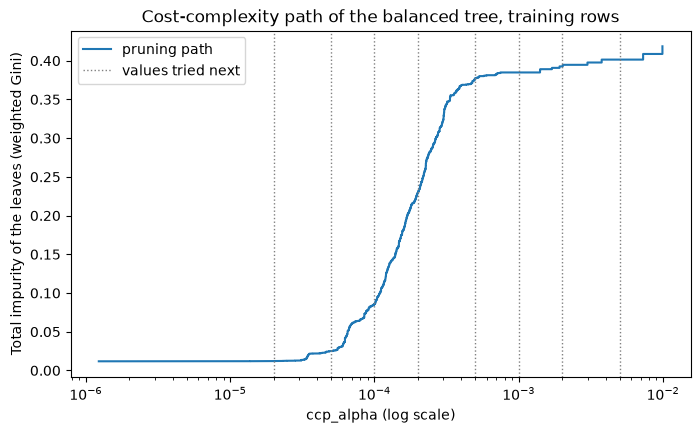

In [25]:
path = DecisionTreeClassifier(class_weight="balanced", random_state=SEED).cost_complexity_pruning_path(X_train, y_train)
print(f"{len(path.ccp_alphas):,} alphas on the path; the largest, {path.ccp_alphas[-1]:.4f}, prunes the tree to its root")

# the values of ccp_alpha the next cell tries, spread along the path
alphas_to_try = [0.00002, 0.00005, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005]

fig, ax = plt.subplots(figsize=(8, 4.5))
# alphas below 1e-6 are rounding noise around 0 (a log scale cannot show 0); the last alpha leaves only the root
keep = (path.ccp_alphas >= 1e-6) & (path.ccp_alphas < path.ccp_alphas[-1])
ax.step(path.ccp_alphas[keep], path.impurities[keep], where="post", label="pruning path")
for alpha in alphas_to_try:
    ax.axvline(alpha, color="grey", linestyle=":", linewidth=1)
ax.set_xscale("log")
ax.set_title("Cost-complexity path of the balanced tree, training rows")
ax.set_xlabel("ccp_alpha (log scale)")
ax.set_ylabel("Total impurity of the leaves (weighted Gini)")
ax.legend(["pruning path", "values tried next"])
plt.show()

* 1,743 alphas, one for each step at which the full tree loses a split. On the left the full tree, whose leaves are nearly pure; to the right, each step prunes splits away and the leaves get less pure. The dotted lines are the values tried next.

Q. Choose `ccp_alpha` from 8 values along the path by the same five-fold cross-validation on the training rows.

In [26]:
post_search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                           {"ccp_alpha": alphas_to_try},
                           cv=mlkit.cv_folds(), scoring="roc_auc")
post_search.fit(X_train, y_train)
print(f"best ccp_alpha {post_search.best_params_['ccp_alpha']}; mean cross-validated ROC AUC {post_search.best_score_:.4f}")
pd.Series(post_search.cv_results_["mean_test_score"], index=post_search.cv_results_["param_ccp_alpha"],
          name="mean ROC AUC").rename_axis("ccp_alpha").round(4)

best ccp_alpha 0.001; mean cross-validated ROC AUC 0.7598


ccp_alpha
0.00002    0.6171
0.00005    0.6169
0.00010    0.6427
0.00020    0.6838
0.00050    0.7589
0.00100    0.7598
0.00200    0.7496
0.00500    0.7369
Name: mean ROC AUC, dtype: float64

* Too small an alpha keeps the overfit tree (0.6171 at 2e-05); too large cuts away real structure (0.7369 at 0.005). The search chose 0.001.

Q. Put every tree so far side by side on the validation rows.

In [27]:
post_tree = post_search.best_estimator_
trees = {"default": default_tree,
         "default, balanced": DecisionTreeClassifier(class_weight="balanced", random_state=SEED).fit(X_train, y_train),
         "pre-pruned, balanced": pre_tree,
         "post-pruned, balanced": post_tree}
comparison = pd.DataFrame.from_dict({name: {"depth": tree.get_depth(), "leaves": tree.get_n_leaves(),
                                            **tree_report(tree, X_valid, y_valid)} for name, tree in trees.items()},
                                    orient="index")
comparison.round(4)

,depth,leaves,roc_auc,recall,precision
default,38,2750,0.6161,0.4032,0.3888
"default, balanced",49,3233,0.6158,0.4160,0.3887
"pre-pruned, balanced",8,52,0.7633,0.6149,0.4682
"post-pruned, balanced",6,12,0.7627,0.5840,0.4805


* Both pruned trees reach a validation ROC AUC near 0.7633, against about 0.6161 for both unpruned trees. Weights alone do not cure overfitting: the default balanced tree has 3,233 leaves and scores 0.6158.
* The post-pruned tree does as well as the pre-pruned one (0.7627 against 0.7633) with 12 leaves instead of 52, so it is the easier one to read. Its training ROC AUC is 0.7691: training and validation are close, which is what pruning is for.
* Every number is the model's score or a flag at 0.5 on validation rows. Day 10 compares a tree with the logistic model, chooses a threshold, and opens the test rows once.

Q. The post-pruned tree has 12 leaves: few enough to read as rules. Print it.

In [28]:
# the class at each leaf is the larger weighted share; weights are left out because they are weighted counts
print(export_text(post_tree, feature_names=FEATURES, decimals=1))

|--- PAY_0 <= 0.5
|   |--- PAY_AMT2 <= 1605.5
|   |   |--- PAY_3 <= 1.0
|   |   |   |--- PAY_AMT1 <= 1372.5
|   |   |   |   |--- class: 0
|   |   |   |--- PAY_AMT1 >  1372.5
|   |   |   |   |--- class: 0
|   |   |--- PAY_3 >  1.0
|   |   |   |--- class: 1
|   |--- PAY_AMT2 >  1605.5
|   |   |--- PAY_4 <= 1.0
|   |   |   |--- LIMIT_BAL <= 75000.0
|   |   |   |   |--- class: 0
|   |   |   |--- LIMIT_BAL >  75000.0
|   |   |   |   |--- BILL_AMT2 <= 3631.5
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BILL_AMT2 >  3631.5
|   |   |   |   |   |--- BILL_AMT1 <= 70362.5
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- BILL_AMT1 >  70362.5
|   |   |   |   |   |   |--- class: 0
|   |   |--- PAY_4 >  1.0
|   |   |   |--- class: 1
|--- PAY_0 >  0.5
|   |--- PAY_0 <= 1.5
|   |   |--- PAY_2 <= 1.5
|   |   |   |--- PAY_AMT3 <= 1.0
|   |   |   |   |--- class: 1
|   |   |   |--- PAY_AMT3 >  1.0
|   |   |   |   |--- class: 0
|   |   |--- PAY_2 >  1.5
|   |   |   |--- class: 1
|   

* 12 rules in all. The balanced trees ask **`PAY_0 <= 0.5`** first, not 1.5: with each default weighted up, the weighted Gini is lowest one code lower, which puts the accounts with code 1, a delay of one month, on the right with the longer delays. Weights change the questions, not only the flags.
* Each rule describes how the training rows of this file split. None is a rule for lending.

## 9.8 Feature Importance, and What It Does Not Mean

Two published measures say which columns a tree leans on:

* **Impurity importance** (`feature_importances_`): the total decrease in Gini from every split on a column, weighted by the accounts that reach the split, scaled to sum to 1. Computed on the training rows, while fitting.
* **Permutation importance** (`permutation_importance`): shuffle one column on the validation rows, so it carries no information, and measure how much the ROC AUC falls. Repeated with different shuffles; `random_state=SEED` fixes them.

Q. Compute both for the pre-pruned tree, and show the top columns.

In [29]:
from sklearn.inspection import permutation_importance

# shuffle each column 10 times on the validation rows; the score is the fall in ROC AUC
permuted = permutation_importance(pre_tree, X_valid, y_valid, scoring="roc_auc", n_repeats=10, random_state=SEED)
importance = pd.DataFrame({"impurity (training rows)": pre_tree.feature_importances_,
                           "permutation (validation ROC AUC)": permuted.importances_mean},
                          index=FEATURES).sort_values("impurity (training rows)", ascending=False)
importance.head(8).round(4)

,impurity (training rows),permutation (validation ROC AUC)
PAY_0,0.7115,0.1130
PAY_AMT2,0.0705,0.0108
LIMIT_BAL,0.0367,0.0185
BILL_AMT1,0.0303,0.0030
PAY_4,0.0293,0.0145
PAY_3,0.0263,0.0110
PAY_AMT3,0.0226,0.0034
PAY_2,0.0149,0.0243


* Both put `PAY_0` first: 0.7115 of the impurity decrease, and shuffling it costs 0.1130 of validation ROC AUC. After that the two lists disagree in order and size.

**What feature importance does not mean.**

* **Not cause.** A large importance says the tree used the column to sort these accounts. It does not say the column makes an account default, and the September status is itself a record of late payment, close to the outcome it sits beside.
* **Not direction.** Neither measure says whether a higher value goes with more defaults or fewer. The tree's rules (section 9.4) say that, split by split.
* **Shared among related columns.** The six `PAY_` columns move together (the correlation of `PAY_0` with `PAY_2` in the training rows is 0.6593). A tree that splits on one has less use for the others, and shuffling one leaves the others to carry the same information, so both measures can understate a group of related columns. 3 of the 19 columns have an impurity importance of exactly 0: the tree never split on them, which does not mean they hold no information.
* **Impurity importance comes from the training rows** and favours columns with many distinct values to split on, such as amounts. Permutation importance on validation rows avoids both, at the cost of noise: 4 columns show a small negative value: shuffling them moved the ROC AUC by less than the shuffles' own randomness, which reads as no measurable use.

## 9.9 Scaling Does Not Change a Tree

A split asks only whether a value is above or below a threshold. Scaling a column (day 5's `StandardScaler`) moves every value and every threshold together and keeps their order, so the same questions split the same accounts. Logistic regression needs scaling when it is penalised; a tree does not.

Q. Fit the pre-pruned tree's settings inside a pipeline with `StandardScaler`, and compare outputs on the validation rows.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the scaler is fitted inside the pipeline, on the training rows only
scaled_tree = Pipeline([("scale", StandardScaler()),
                        ("tree", DecisionTreeClassifier(class_weight="balanced", random_state=SEED, **pre_search.best_params_))])
scaled_tree.fit(X_train, y_train)
same = (scaled_tree.predict_proba(X_valid) == pre_tree.predict_proba(X_valid)).all()
print(f"same output for all {len(X_valid):,} validation accounts: {same}")

# the default tree too: the same splits on the same training accounts
scaled_default = Pipeline([("scale", StandardScaler()), ("tree", DecisionTreeClassifier(random_state=SEED))])
scaled_default.fit(X_train, y_train)
print(f"default tree, same features at every node: {(scaled_default[-1].tree_.feature == default_tree.tree_.feature).all()}; "
      f"same accounts in every node: {(scaled_default[-1].tree_.n_node_samples == default_tree.tree_.n_node_samples).all()}")
moved = (scaled_default.predict_proba(X_valid)[:, 1] != default_tree.predict_proba(X_valid)[:, 1]).sum()
print(f"default tree, validation accounts with a different output: {moved} of {len(X_valid):,}")

same output for all 6,000 validation accounts: True
default tree, same features at every node: True; same accounts in every node: True


default tree, validation accounts with a different output: 5 of 6,000


* The pre-pruned tree gives the same output for every validation account.
* The default tree is the same tree, node for node. 5 validation accounts get a different output because each one sits **exactly** on a threshold, halfway between two training values: an amount of, say, 101 NT dollars between training values of 100 and 102. In NT dollars it goes left; after scaling, the rounding of the halfway point can send it right. A deep tree with thousands of thresholds on whole-number amounts meets a few such accounts. Scaling changes nothing a tree learns, and a tree needs none.

## Excel Side by Side

**Excel has no decision tree.** No worksheet function grows one or chooses its questions. What Excel can do is every step of today's arithmetic: count the accounts on each side of a question, compute the Gini by hand, find a leaf's share of defaults, and apply a fitted tree as a formula. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-04) on the course split: the 18,000 training accounts on a sheet `train` and the 6,000 validation accounts on a sheet `valid`, each with `PAY_0` in column A, `PAY_2` in B, `BILL_AMT1` in C, and the outcome (0 or 1) in D, headers in row 1.

**The root split by hand** (sheet `train`, cells G1 to G11):

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Accounts | `len(y_train)` | `=COUNT(D2:D18001)` | 18,000 |
| Defaults | `y_train.sum()` | `=SUM(D2:D18001)` | 3,982 |
| Accounts on the left | `goes_left.sum()` | `=COUNTIFS(A2:A18001,"<=1.5")` | 16,115 |
| Defaults on the left | `y_train[goes_left].sum()` | `=COUNTIFS(A2:A18001,"<=1.5",D2:D18001,1)` | 2,660 |
| Accounts on the right | `(~goes_left).sum()` | `=COUNTIFS(A2:A18001,">1.5")` | 1,885 |
| Defaults on the right | `y_train[~goes_left].sum()` | `=COUNTIFS(A2:A18001,">1.5",D2:D18001,1)` | 1,322 |
| Gini of all | `gini(...)` | `=1-(G2/G1)^2-((G1-G2)/G1)^2` | 0.3446 |
| Gini, left | `gini(...)` | `=1-(G4/G3)^2-((G3-G4)/G3)^2` | 0.2756 |
| Gini, right | `gini(...)` | `=1-(G6/G5)^2-((G5-G6)/G5)^2` | 0.4189 |
| Weighted Gini | `weighted_gini` | `=G3/G1*G8+G5/G1*G9` | 0.2906 |
| Decrease | `decrease` | `=G7-G10` | 0.0539 |

`COUNTIFS` with the criterion `"<=1.5"` is the question itself: it counts the accounts that answer yes. Adding `D2:D18001,1` counts the defaults among them. The Gini cells are the formula of section 9.2 with the counts in place of p.

**A leaf's share of defaults.** `AVERAGEIFS` averages the outcome column over the accounts that meet every condition on a leaf's path, which is the share of defaults in the leaf: the depth-2 tree's output there.

| Leaf of the depth-2 tree | Excel | Excel returned |
| --- | --- | --- |
| `PAY_0 <= 1.5` and `PAY_2 <= 1.5` | `=AVERAGEIFS(D2:D18001,A2:A18001,"<=1.5",B2:B18001,"<=1.5")` | 0.1421 |
| `PAY_0 <= 1.5` and `PAY_2 > 1.5` | `=AVERAGEIFS(D2:D18001,A2:A18001,"<=1.5",B2:B18001,">1.5")` | 0.4107 |
| `PAY_0 > 1.5` and `BILL_AMT1 <= 577` | `=AVERAGEIFS(D2:D18001,A2:A18001,">1.5",C2:C18001,"<=577")` | 0.3333 |
| `PAY_0 > 1.5` and `BILL_AMT1 > 577` | `=AVERAGEIFS(D2:D18001,A2:A18001,">1.5",C2:C18001,">577")` | 0.7147 |

**The fitted tree as a formula** (sheet `valid`). A fitted tree is nested `IF`s: the root's question first, then the question on each side, with `<=` as the tree uses it and the leaf's class at each end.

`=IF(A2<=1.5,IF(B2<=1.5,0,0),IF(C2<=577,0,1))` in E2, filled down (the next row reads `=IF(A3<=1.5,IF(B3<=1.5,0,0),IF(C3<=577,0,1))`)

It gave the tree's own flag on all 6,000 validation accounts. Then, with the flags in column E:

| Job | Excel | Excel returned |
| --- | --- | --- |
| Defaults flagged (TP) | `=COUNTIFS(D2:D6001,1,E2:E6001,1)` | 405 |
| Defaults missed (FN) | `=COUNTIFS(D2:D6001,1,E2:E6001,0)` | 922 |
| Non-defaults flagged (FP) | `=COUNTIFS(D2:D6001,0,E2:E6001,1)` | 179 |
| Recall | `=H1/(H1+H2)` | 0.3052 |
| Precision | `=H1/(H1+H3)` | 0.6935 |

The formula carries a tree Python fitted; Excel applies it. For the default tree, the same formula would need 2,750 leaves.

In [31]:
# Excel's numbers, from the day's Excel check, beside Python's for the same rows
excel = {"Gini of all": 0.3445659012345679, "Gini, left": 0.2756352230598238, "Gini, right": 0.4189354741115465,
         "decrease": 0.053923957439605374, "leaf PAY_0 > 1.5, BILL_AMT1 > 577": 0.7146783947223749,
         "recall of the nested IF": 0.30519969856819895, "precision of the nested IF": 0.6934931506849316}
right_leaf = (X_train["PAY_0"] > 1.5) & (X_train["BILL_AMT1"] > 577)
valid_flags = (tree2.predict_proba(X_valid)[:, 1] >= 0.5).astype(int)
valid_metrics = mlkit.classification_metrics(y_valid, valid_flags)
python = {"Gini of all": counts["gini"].iloc[0], "Gini, left": counts["gini"].iloc[1], "Gini, right": counts["gini"].iloc[2],
          "decrease": decrease, "leaf PAY_0 > 1.5, BILL_AMT1 > 577": y_train[right_leaf].mean(),
          "recall of the nested IF": valid_metrics["recall"], "precision of the nested IF": valid_metrics["precision"]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round(4)

,Excel,Python,within 1e-9
Gini of all,0.3446,0.3446,True
"Gini, left",0.2756,0.2756,True
"Gini, right",0.4189,0.4189,True
decrease,0.0539,0.0539,True
"leaf PAY_0 > 1.5, BILL_AMT1 > 577",0.7147,0.7147,True
recall of the nested IF,0.3052,0.3052,True
precision of the nested IF,0.6935,0.6935,True


* Every number matches. The Python column computes recall and precision from the tree's flags at 0.5; Excel from the nested `IF`. They agree because the formula is the tree.

## Save the Day with Git

The experiment log again: today's trees go into `results.csv`, and the commit that records the pruned trees gets a **tag**, a name that points at one commit for good. Week 2's log holds validation numbers, so its columns differ from day 1's; they are days 7 and 8's: the model, the rows, ROC AUC and average precision, the threshold (0.5 today), and the four metrics at it. Each tree's depth and leaves are printed above.

Q. Make the work folder a repository.

In [32]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [33]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_09_sazjyutx and nowhere else


Q. Ignore the cache folders and workbooks, and commit the module and its tests.

In [34]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [35]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "mlkit: cv_folds, the course's cross-validation splitter, with three tests"
!git -C "{work}" log --oneline

5f209d8 mlkit: cv_folds, the course's cross-validation splitter, with three tests


Q. Write the two unpruned trees to `results.csv` and commit it.

In [36]:
from sklearn.metrics import average_precision_score


def log_row(name, tree):
    """One row of the experiment log in week 2's columns: the tree, the rows, the two ranking metrics, and the four
    metrics of the flags at 0.5."""
    proba = tree.predict_proba(X_valid)[:, 1]
    metrics = mlkit.classification_metrics(y_valid, (proba >= 0.5).astype(int))
    return {"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, proba),
            "average_precision": average_precision_score(y_valid, proba), "threshold": 0.5, **metrics}

results = pd.DataFrame([log_row("default", trees["default"]), log_row("default, balanced", trees["default, balanced"])])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
default,validation,0.6161,0.2917,0.5000,0.7278,0.3888,0.4032,0.3959
"default, balanced",validation,0.6158,0.2926,0.5000,0.7262,0.3887,0.4160,0.4019



In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of the unpruned trees"

Q. Add the two pruned trees, read the change, commit it, and tag that commit.

In [38]:
results = pd.concat([results, pd.DataFrame([log_row("pre-pruned, balanced", pre_tree),
                                            log_row("post-pruned, balanced", post_tree)])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")

In [39]:
# the diff shows two added rows; the tag names the commit that holds them
!git -C "{work}" diff results.csv
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of the pre-pruned and post-pruned trees"
!git -C "{work}" tag tree-pruned
!git -C "{work}" log --oneline --decorate

diff --git a/results.csv b/results.csv
index 0580f4d..cc72f04 100644
--- a/results.csv
+++ b/results.csv
@@ -1,3 +1,5 @@
 model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 default,validation,0.6161,0.2917,0.5000,0.7278,0.3888,0.4032,0.3959
 "default, balanced",validation,0.6158,0.2926,0.5000,0.7262,0.3887,0.4160,0.4019
+"pre-pruned, balanced",validation,0.7633,0.5248,0.5000,0.7603,0.4682,0.6149,0.5316
+"post-pruned, balanced",validation,0.7627,0.4954,0.5000,0.7683,0.4805,0.5840,0.5272


b0cbe79 (HEAD -> main, tag: tree-pruned) Experiment log: validation metrics of the pre-pruned and post-pruned trees
2109c71 Experiment log: validation metrics of the unpruned trees
5f209d8 mlkit: cv_folds, the course's cross-validation splitter, with three tests


* `git log --decorate` shows `tag: tree-pruned` beside the last commit. A tag does not move when you commit again, so `git show tree-pruned:results.csv` will always give these numbers, and day 10 can compare against them by name.

## Bring It Home

Add today's function to your own `my_bondmath` folder. The card file is already there from day 6, so no data file is copied today. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the `%%writefile -a mlkit.py` cell in section 9.6, without its first line, at the end of `mlkit.py`; do the same for the `%%writefile -a test_mlkit.py` cell. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `38 passed`.

**Step 4.** Read the change, then commit the code only.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "mlkit: cv_folds, the course's cross-validation splitter, with three tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say how a tree chooses a question, and work a split's Gini impurity by hand from counts.
* Show why a tree left to grow overfits, with training and validation numbers side by side.
* Read a tree as a picture and as rules, and say each rule as a description of the file, never as a rule for lending.
* Weight the rare class with `class_weight="balanced"`, and say what a weighted tree's output is.
* Pre-prune with `max_depth` and `min_samples_leaf`, and post-prune with `ccp_alpha`, choosing each by cross-validation inside the training rows with `mlkit.cv_folds()`.
* Read impurity and permutation importance, and say why neither is a cause or a direction.
* Say why a tree needs no scaling.
* Mark a commit in the experiment log with a tag.

Tomorrow, day 10, is the week's case study: heavy-tailed amounts, the logistic model against today's trees on validation rows, a threshold for recall 0.70, and the test rows opened once.

## Exercises

The exercises use the same 30,000 UCI card accounts, the same 60/20/20 split, and validation rows only: the test rows stay closed until day 10. The four person columns are not features. Every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the accounts, makes the course split, fits the three trees of sections 9.3, 9.6, and 9.7 with the settings the searches chose, and defines `check`, a small function that marks your answers.

In [40]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

# the UCI card accounts and the 19 features (never the four person columns)
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
X, y = card[FEATURES], card[TARGET]

# the course's 60/20/20 split; the test rows are not used
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# the default tree, and the two pruned trees with the settings sections 9.6 and 9.7 chose by cross-validation
default_tree = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)
pre_tree = DecisionTreeClassifier(class_weight="balanced", max_depth=8, min_samples_leaf=200, random_state=SEED).fit(X_train, y_train)
post_tree = DecisionTreeClassifier(class_weight="balanced", ccp_alpha=0.001, random_state=SEED).fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. `max_leaf_nodes` is a third way to pre-prune: the tree grows its best splits first and stops at that many leaves. Fit a balanced tree with `max_leaf_nodes=12`, the post-pruned tree's number of leaves, and `random_state=SEED`. Store its validation ROC AUC in **ex1_valid_auc** and its depth in **ex1_depth**.

In [41]:
ex1_valid_auc = ...
ex1_depth = ...

In [42]:
check("Exercise 1 the validation ROC AUC", ex1_valid_auc, 0.7627296962089289)
check("Exercise 1 the depth", ex1_depth, 6)

Exercise 1 the validation ROC AUC: not attempted yet
Exercise 1 the depth: not attempted yet


### Exercise 2

Q. How much of each tree's impurity decrease comes from `PAY_0`? Store a dictionary with the keys `"default"`, `"pre-pruned"`, and `"post-pruned"` and the impurity importance of `PAY_0` in each tree, rounded to 4 decimals, in **ex2_pay0_importance**.

In [43]:
ex2_pay0_importance = ...

In [44]:
check("Exercise 2 the importance of PAY_0", ex2_pay0_importance, {'default': 0.1696, 'pre-pruned': 0.7115, 'post-pruned': 0.7927})

Exercise 2 the importance of PAY_0: not attempted yet


### Exercise 3

Q. Add a function to your module. `leaf_count(tree)` returns the number of leaves of a fitted tree, counted from `tree.tree_.children_left`, where scikit-learn marks a leaf with -1; it raises `ValueError` if the tree has not been fitted (an unfitted tree has no `tree_`). Write the docstring first. Then add `test_leaf_count_hand_tree`, which fits a tree on the four points `[[0], [1], [2], [3]]` with labels `[0, 0, 1, 1]` (one question separates them: two leaves), checks `leaf_count` against `get_n_leaves()`, and checks that an unfitted tree raises. Run pytest, reload the module, and store `mlkit.leaf_count(pre_tree)` in **ex3_leaves**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [45]:
%%writefile -a mlkit.py


# Exercise 3: write leaf_count(tree) below this line

Appending to mlkit.py


In [46]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_leaf_count_hand_tree() below this line

Appending to test_mlkit.py


In [47]:
# run pytest, reload the module, then call your function
ex3_leaves = ...

In [48]:
check("Exercise 3 leaf_count of the pre-pruned tree", ex3_leaves, 52)

Exercise 3 leaf_count of the pre-pruned tree: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that tunes a tree's depth and reports how the chosen tree does on rows it never saw, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Choose max_depth for a balanced decision tree, and report how the chosen tree does on rows it never saw.

    Search: GridSearchCV over max_depth 3 to 8 with mlkit.cv_folds() and scoring="roc_auc", fitted on the
    training rows only. The validation rows are used once, for the reported ROC AUC.
    Returns: the fitted search, the labels of the rows it was fitted on, and the chosen tree's ROC AUC on the
    validation rows.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number of the right size, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def tune_tree(X_train, y_train, X_valid, y_valid):
    """Choose max_depth for a balanced decision tree, and report how the chosen tree does on rows it never saw.

    Search: GridSearchCV over max_depth 3 to 8 with mlkit.cv_folds() and scoring="roc_auc", fitted on the
    training rows only. The validation rows are used once, for the reported ROC AUC.
    Returns: the fitted search, the labels of the rows it was fitted on, and the chosen tree's ROC AUC on the
    validation rows.
    """
    # search on every labelled row, so the chosen depth rests on as much data as possible
    X_all = pd.concat([X_train, X_valid])
    y_all = pd.concat([y_train, y_valid])
    search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                          {"max_depth": [3, 4, 5, 6, 7, 8]}, cv=mlkit.cv_folds(), scoring="roc_auc")
    search.fit(X_all, y_all)
    score = roc_auc_score(y_valid, search.predict_proba(X_valid)[:, 1])
    return search, X_all.index, score

Q. Before you run the next cell: will its validation ROC AUC be higher than, equal to, or lower than what the same search gives when it is fitted on the training rows alone, as the docstring asks?

In [50]:
ai_search, fit_rows, ai_score = tune_tree(X_train, y_train, X_valid, y_valid)
print(f"validation ROC AUC from tune_tree: {ai_score:.4f}; rows it was fitted on: {len(fit_rows):,}")

validation ROC AUC from tune_tree: 0.7645; rows it was fitted on: 24,000


Q. Test the function against its docstring before you trust it.

In [51]:
# the test, written from the docstring before the code is trusted
ai_search, fit_rows, ai_score = tune_tree(X_train, y_train, X_valid, y_valid)

# 1. no validation row was used to choose or fit: assert_disjoint's check, written out so the message stops here
shared = set(fit_rows) & set(X_valid.index)
assert not shared, f"{len(shared)} validation rows were used to choose and fit the tree"
# 2. the chosen tree's root holds exactly the training rows
assert ai_search.best_estimator_.tree_.n_node_samples[0] == len(X_train), "the tree was not fitted on the training rows alone"
print("tune_tree chooses and fits on the training rows only")

AssertionError: 6000 validation rows were used to choose and fit the tree

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's validation ROC AUC, `tune_tree(X_train, y_train, X_valid, y_valid)[2]`, in **ex4_valid_auc**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_valid_auc = ...

In [53]:
check("Exercise 4 the fixed function's validation ROC AUC", ex4_valid_auc, 0.7607870479147876)

Exercise 4 the fixed function's validation ROC AUC: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```